# Double ML causal inference

### Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import doubleml as dml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

alpha = 0.1
sns.set_style("whitegrid")

### Данные

In [2]:
df = pd.read_csv("data/final_dataset.csv")
df_men = df[df["sex"] == 1]
df_women = df[df["sex"] == 2]

In [3]:
df_men

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
16,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
4589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [4]:
df_women

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4591,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Женщины и гипертония

In [5]:
treatment = "diploma"
outcome = "hypertension"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

In [6]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [7]:
ml_g = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)
ml_m = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)

dml_irm = dml.DoubleMLIRM(
    dml_data_women,
    ml_g=ml_g,
    ml_m=ml_m,
    trimming_threshold=0.01,
    n_folds=5,
    score="ATE",
)

dml_irm.fit()

print(dml_irm.summary)
print()
print(dml_irm.confint(level=1 - alpha))

             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.030609  0.015525 -1.971604  0.048655 -0.061036 -0.000181

            5.0 %    95.0 %
diploma -0.056144 -0.005073


### Женщины и заболевания глаз

In [8]:
treatment = "diploma"
outcome = "eyes"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

In [9]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [10]:
ml_g = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)
ml_m = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)

dml_irm = dml.DoubleMLIRM(
    dml_data_women,
    ml_g=ml_g,
    ml_m=ml_m,
    trimming_threshold=0.01,
    n_folds=5,
    score="ATE",
)

dml_irm.fit()

print(dml_irm.summary)
print()
print(dml_irm.confint(level=1 - alpha))

             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.017024  0.013627  1.249222  0.211584 -0.009686  0.043733

            5.0 %    95.0 %
diploma -0.005391  0.039438


### Женщины и аллергия

In [11]:
treatment = "diploma"
outcome = "allergy"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

In [12]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [13]:
ml_g = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)
ml_m = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)

dml_irm = dml.DoubleMLIRM(
    dml_data_women,
    ml_g=ml_g,
    ml_m=ml_m,
    trimming_threshold=0.01,
    n_folds=5,
    score="ATE",
)

dml_irm.fit()

print(dml_irm.summary)
print()
print(dml_irm.confint(level=1 - alpha))

            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.00714  0.010792 -0.661649  0.508197 -0.028292  0.014011

            5.0 %    95.0 %
diploma -0.024892  0.010611


### Мужчины и оценка состояния здоровья

In [14]:
treatment = "diploma"
outcome = "is_health_very_good"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

In [15]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [16]:
ml_g = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)
ml_m = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
)

dml_irm = dml.DoubleMLIRM(
    dml_data_men,
    ml_g=ml_g,
    ml_m=ml_m,
    trimming_threshold=0.01,
    n_folds=5,
    score="ATE",
)

dml_irm.fit()

print(dml_irm.summary)
print()
print(dml_irm.confint(level=1 - alpha))

            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.00465  0.005324 -0.873492  0.382395 -0.015085  0.005784

            5.0 %    95.0 %
diploma -0.013408  0.004107


### Другие интересные наблюдения

In [17]:
treatment = "diploma"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

diseases = [
    "heart",
    "lungs",
    "liver",
    "kidneys",
    "stomach",
    "spine",
    "diabetes",
    "hypertension",
    "joints",
    "ENT_organs",
    "neurology",
    "eyes",
    "allergy",
    "veins",
    "skin",
    "oncology",
    "is_health_good",
    "is_health_very_good",
]

for outcome in diseases:
    dml_data_women = dml.DoubleMLData(
        df_women, y_col=outcome, d_cols=treatment, x_cols=controls
    )
    dml_data_men = dml.DoubleMLData(
        df_men, y_col=outcome, d_cols=treatment, x_cols=controls
    )

    ml_g = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
    )
    ml_m = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
    )

    dml_irm_women = dml.DoubleMLIRM(
        dml_data_women,
        ml_g=ml_g,
        ml_m=ml_m,
        trimming_threshold=0.01,
        n_folds=5,
        score="ATE",
    )
    dml_irm_women.fit()

    p_val_w = dml_irm_women.pval.item()

    if p_val_w <= alpha:
        print(f"Women - {outcome}:")
        print(dml_irm_women.summary)
        print()
        print(dml_irm_women.confint(level=1 - alpha))
    else:
        print(f"Women - {outcome}: no effect")
    print(3 * "\n")

    ml_g = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
    )
    ml_m = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
    )

    dml_irm_men = dml.DoubleMLIRM(
        dml_data_men,
        ml_g=ml_g,
        ml_m=ml_m,
        trimming_threshold=0.01,
        n_folds=5,
        score="ATE",
    )
    dml_irm_men.fit()

    p_val_m = dml_irm_men.pval.item()

    if p_val_m <= alpha:
        print(f"Men - {outcome}:")
        print(dml_irm_men.summary)
        print()
        print(dml_irm_men.confint(level=1 - alpha))
    else:
        print(f"Men - {outcome}: no effect")
    print(3 * "\n")

Women - heart: no effect




Men - heart:
             coef   std err         t     P>|t|    2.5 %    97.5 %
diploma  0.029741  0.012695  2.342781  0.019141  0.00486  0.054623

           5.0 %    95.0 %
diploma  0.00886  0.050623




Women - lungs:
             coef   std err        t     P>|t|     2.5 %    97.5 %
diploma -0.040582  0.009261 -4.38206  0.000012 -0.058732 -0.022431

            5.0 %    95.0 %
diploma -0.055814 -0.025349




Men - lungs: no effect




Women - liver: no effect




Men - liver: no effect




Women - kidneys:
            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.02222  0.008884 -2.501227  0.012376 -0.039632 -0.004808

            5.0 %    95.0 %
diploma -0.036833 -0.007608




Men - kidneys: no effect




Women - stomach: no effect




Men - stomach: no effect




Women - spine:
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.030628  0.013996 -2.188318  0.028646 -0.058059 -0.003196

            5.0 %  

In [18]:
treatment = "diploma"
controls = [
    "age",
    "mar_st",
    "invalid",
    "type_area",
    "income",
    "n_child",
    "alcohol",
    "smoking",
    "phys_active",
]

diseases = [
    "heart",
    "lungs",
    "liver",
    "kidneys",
    "stomach",
    "spine",
    "diabetes",
    "hypertension",
    "joints",
    "ENT_organs",
    "neurology",
    "eyes",
    "allergy",
    "veins",
    "skin",
    "oncology",
    "is_health_good",
    "is_health_very_good",
]

forest_results = []

for outcome in diseases:
    dml_data_w = dml.DoubleMLData(
        df_women, y_col=outcome, d_cols=treatment, x_cols=controls
    )
    dml_data_m = dml.DoubleMLData(
        df_men, y_col=outcome, d_cols=treatment, x_cols=controls
    )

    for gender, dml_data in [("Women", dml_data_w), ("Men", dml_data_m)]:
        ml_g = RandomForestClassifier(
            n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
        )
        ml_m = RandomForestClassifier(
            n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
        )
        dml_irm = dml.DoubleMLIRM(
            dml_data,
            ml_g=ml_g,
            ml_m=ml_m,
            trimming_threshold=0.01,
            n_folds=5,
            score="ATE",
        )
        dml_irm.fit()

        ci = dml_irm.confint(level=1 - alpha)
        forest_results.append({
            "outcome": outcome,
            "gender": gender,
            "coef": dml_irm.coef.item(),
            "ci_low": ci.iloc[0, 0],
            "ci_high": ci.iloc[0, 1],
            "significant": dml_irm.pval.item() <= alpha,
        })

print(f"Collected {len(forest_results)} estimates.")

Collected 36 estimates.


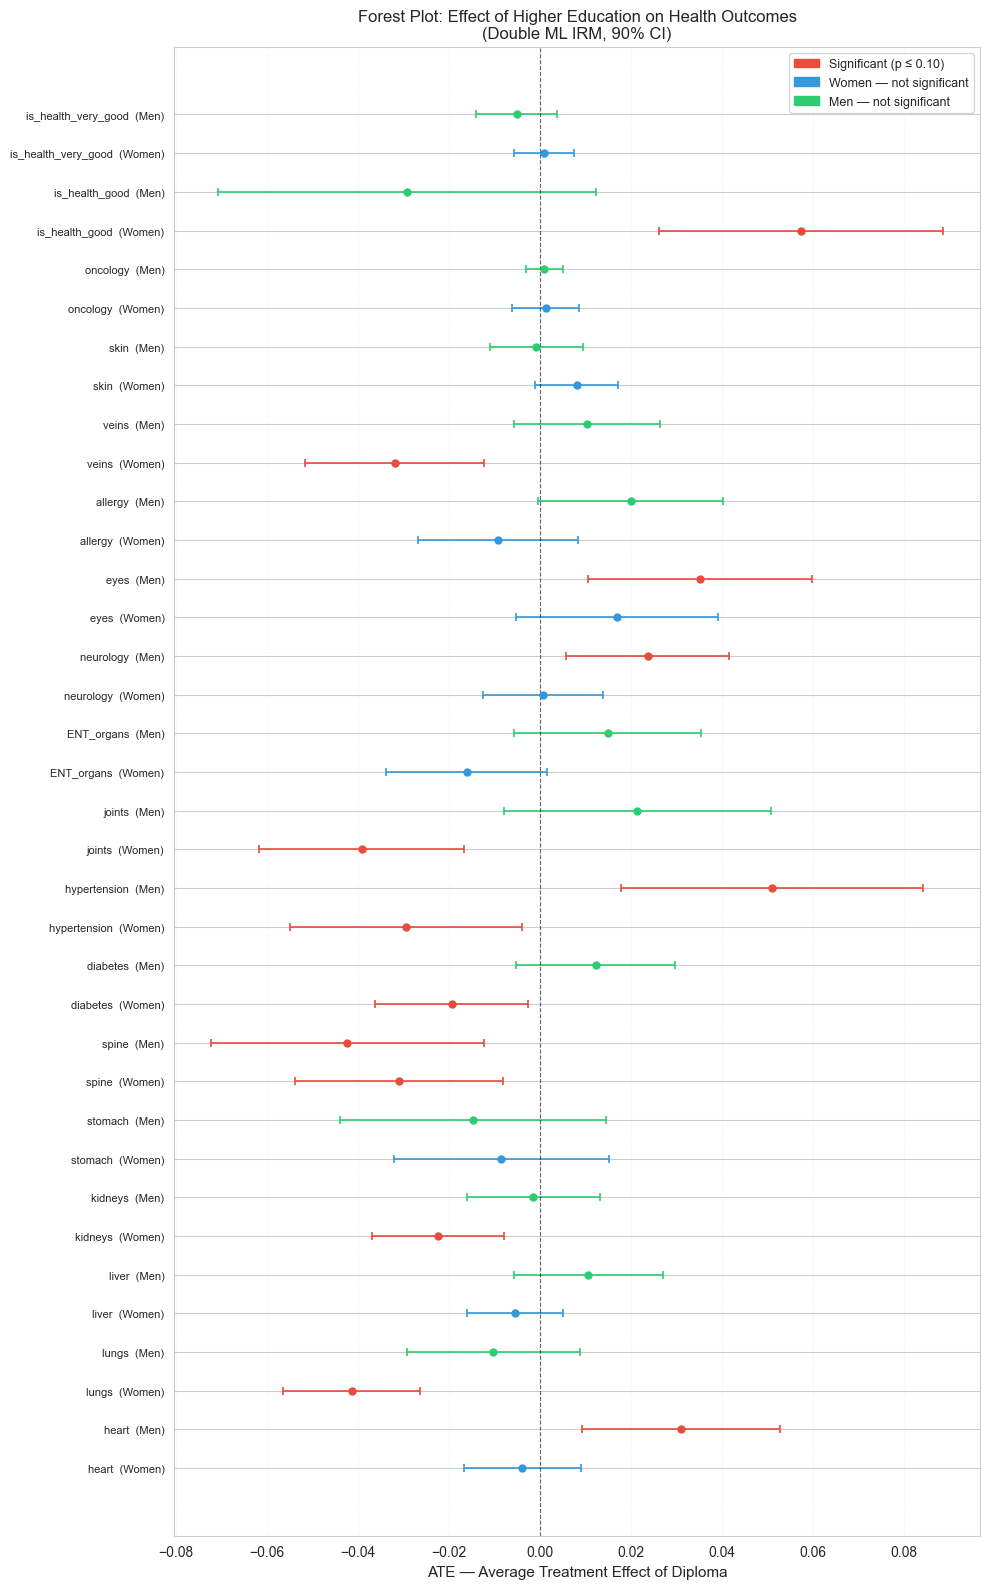

In [19]:
fig, ax = plt.subplots(figsize=(10, 16))

y_pos = np.arange(len(forest_results))

for i, r in enumerate(forest_results):
    if r["significant"]:
        color = "#e74c3c"
    elif r["gender"] == "Women":
        color = "#3498db"
    else:
        color = "#2ecc71"

    ax.errorbar(
        r["coef"],
        i,
        xerr=[[r["coef"] - r["ci_low"]], [r["ci_high"] - r["coef"]]],
        fmt="o",
        color=color,
        capsize=3,
        capthick=1.2,
        linewidth=1.2,
        markersize=5,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{r['outcome']}  ({r['gender']})" for r in forest_results], fontsize=8
)
ax.set_xlabel("ATE — Average Treatment Effect of Diploma", fontsize=11)
ax.set_title(
    "Forest Plot: Effect of Higher Education on Health Outcomes\n"
    "(Double ML IRM, 90% CI)",
    fontsize=12,
)
ax.grid(axis="x", alpha=0.3, linestyle=":")

sig_patch = mpatches.Patch(color="#e74c3c", label="Significant (p ≤ 0.10)")
w_patch = mpatches.Patch(color="#3498db", label="Women — not significant")
m_patch = mpatches.Patch(color="#2ecc71", label="Men — not significant")
ax.legend(handles=[sig_patch, w_patch, m_patch], fontsize=9)

plt.tight_layout()
plt.show()

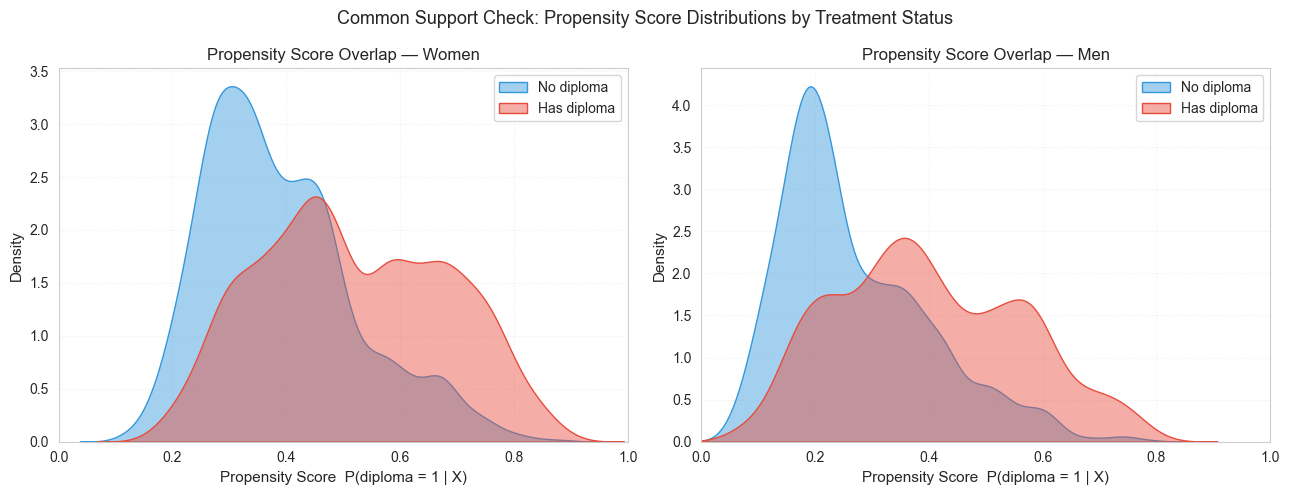

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (df_g, gender) in zip(axes, [(df_women, "Women"), (df_men, "Men")]):
    X = df_g[controls].values
    d = df_g[treatment].values.astype(int)
    clf = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42
    )
    ps = cross_val_predict(clf, X, d, cv=5, method="predict_proba")[:, 1]

    sns.kdeplot(
        ps[d == 0],
        ax=ax,
        label="No diploma",
        fill=True,
        alpha=0.45,
        color="#3498db",
        bw_adjust=0.8,
    )
    sns.kdeplot(
        ps[d == 1],
        ax=ax,
        label="Has diploma",
        fill=True,
        alpha=0.45,
        color="#e74c3c",
        bw_adjust=0.8,
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Propensity Score  P(diploma = 1 | X)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Propensity Score Overlap — {gender}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=":")

plt.suptitle(
    "Common Support Check: Propensity Score Distributions by Treatment Status",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Выводы